<a href="https://colab.research.google.com/github/kudavmahesh88/CSL701-Roll_No_29_Machine-Learning-Lab/blob/main/Experiments/MLexp2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Name:Mahesh vishnu kudav Rollno:CS29

In [1]:
# Task 1: Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Task 2: Load Auto MPG Dataset

url = "/content/auto-mpg.csv"

df = pd.read_csv(url)

df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino


In [3]:
# Task 3: Inspect and Clean Data

df.info()

print("\nMissing Values:")
print(df.isnull().sum())

df["horsepower"] = pd.to_numeric(df["horsepower"], errors="coerce")

df = df.dropna(subset=["horsepower", "mpg"])

print("\nDataset after cleaning:")
print(df.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    398 non-null    object 
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car name      398 non-null    object 
dtypes: float64(3), int64(4), object(2)
memory usage: 28.1+ KB

Missing Values:
mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
model year      0
origin          0
car name        0
dtype: int64

Dataset after cleaning:
(392, 9)


In [4]:
# Task 4: Select Horsepower and MPG

X = df["horsepower"].values
y = df["mpg"].values

print("Horsepower:", X[:5])
print("MPG:", y[:5])

Horsepower: [130. 165. 150. 150. 140.]
MPG: [18. 15. 18. 16. 17.]


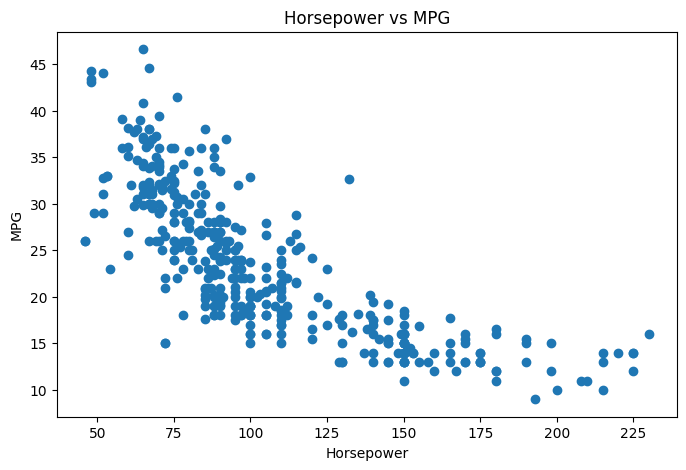

In [5]:
# Task 5: Plot Scatter Graph

plt.figure(figsize=(8, 5))
plt.scatter(X, y)
plt.xlabel("Horsepower")
plt.ylabel("MPG")
plt.title("Horsepower vs MPG")
plt.show()

In [6]:
# Task 6: Add Bias Term

X_matrix = np.column_stack((np.ones(len(X)), X))

print(X_matrix[:5])

[[  1. 130.]
 [  1. 165.]
 [  1. 150.]
 [  1. 150.]
 [  1. 140.]]


In [7]:
# Task 7: Compute Correlation

correlation = np.corrcoef(X, y)[0, 1]

print("Correlation:", correlation)

Correlation: -0.7784267838977756


In [8]:
# Task 8: Calculate OLS Weights

X_transpose = X_matrix.T

weights = np.linalg.inv(X_transpose @ X_matrix) @ X_transpose @ y

print("OLS Weights:")
print(weights)

OLS Weights:
[39.93586102 -0.15784473]


In [9]:
# Task 9: Predict MPG Values

y_pred = X_matrix @ weights

print("First 10 Actual MPG:")
print(y[:10])

print("\nFirst 10 Predicted MPG:")
print(y_pred[:10])

First 10 Actual MPG:
[18. 15. 18. 16. 17. 15. 14. 14. 14. 15.]

First 10 Predicted MPG:
[19.41604569 13.89148002 16.25915102 16.25915102 17.83759835  8.68260382
  5.21001968  5.99924335  4.42079602  9.94536168]


In [10]:
# Task 10: Compute Residuals

residuals = y - y_pred

print("First 10 Residuals:")
print(residuals[:10])

First 10 Residuals:
[-1.41604569  1.10851998  1.74084898 -0.25915102 -0.83759835  6.31739618
  8.78998032  8.00075665  9.57920398  5.05463832]


In [11]:
# Task 11: Calculate SSE, MSE and R²

SSE = np.sum(residuals ** 2)

MSE = np.mean(residuals ** 2)

SST = np.sum((y - np.mean(y)) ** 2)

R2 = 1 - (SSE / SST)

print("SSE:", SSE)
print("MSE:", MSE)
print("R²:", R2)

SSE: 9385.915871932419
MSE: 23.943662938603108
R²: 0.6059482578894348


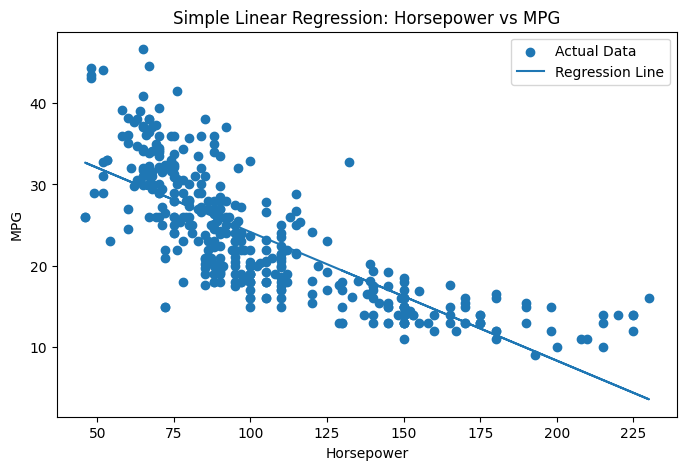

In [12]:
# Task 12: Plot Regression Line

plt.figure(figsize=(8, 5))

plt.scatter(X, y, label="Actual Data")
plt.plot(X, y_pred, label="Regression Line")

plt.xlabel("Horsepower")
plt.ylabel("MPG")
plt.title("Simple Linear Regression: Horsepower vs MPG")

plt.legend()
plt.show()

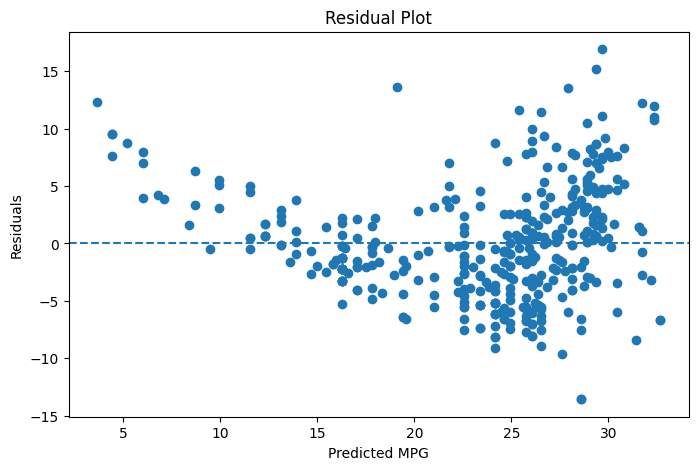

In [13]:
# Task 12: Plot Residual Graph

plt.figure(figsize=(8, 5))

plt.scatter(y_pred, residuals)
plt.axhline(y=0, linestyle="--")

plt.xlabel("Predicted MPG")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.show()

In [14]:
# Task 13: Display Model Results

print("Simple Linear Regression Results")
print("--------------------------------")
print("Intercept (w0):", weights[0])
print("Horsepower coefficient (w1):", weights[1])
print("Correlation:", correlation)
print("SSE:", SSE)
print("MSE:", MSE)
print("R²:", R2)

Simple Linear Regression Results
--------------------------------
Intercept (w0): 39.9358610211705
Horsepower coefficient (w1): -0.15784473335365387
Correlation: -0.7784267838977756
SSE: 9385.915871932419
MSE: 23.943662938603108
R²: 0.6059482578894348
